In [1]:
import zipfile
import os

# Define the path to your zip file and the extraction directory
zip_file_path = '/content/drive/MyDrive/Python/Contents/Copy of FruitinAmazon.zip'
extract_dir = './extracted_content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        print(f"Contents of {zip_file_path}:")
        for name in zip_ref.namelist():
            print(f"- {name}")

        # Extract all contents to the specified directory
        zip_ref.extractall(extract_dir)
        print(f"\nSuccessfully extracted all files to '{extract_dir}'")


except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# List the contents of the extracted directory to verify
print(f"\nContents of '{extract_dir}':")
if os.path.exists(extract_dir):
    for root, dirs, files in os.walk(extract_dir):
        level = root.replace(extract_dir, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print("Extraction directory does not exist.")

Contents of /content/drive/MyDrive/Python/Contents/Copy of FruitinAmazon.zip:
- FruitinAmazon/test/cupuacu/download (5).jpeg
- FruitinAmazon/test/acai/images (2).jpeg
- FruitinAmazon/test/cupuacu/download (3).jpeg
- FruitinAmazon/test/acai/images (16).jpeg
- FruitinAmazon/test/pupunha/download (2).jpeg
- FruitinAmazon/train/pupunha/images (1).jpeg
- FruitinAmazon/test/cupuacu/download (2).jpeg
- FruitinAmazon/test/pupunha/download (1).jpeg
- FruitinAmazon/train/acai/images (3).jpeg
- FruitinAmazon/train/acai/images (4).jpeg
- FruitinAmazon/test/graviola/download (1).jpeg
- FruitinAmazon/test/pupunha/download (11).jpeg
- FruitinAmazon/test/pupunha/download (4).jpeg
- FruitinAmazon/train/acai/images (11).jpeg
- FruitinAmazon/test/tucuma/download (1).jpeg
- FruitinAmazon/test/acai/images.jpeg
- FruitinAmazon/train/acai/images (10).jpeg
- FruitinAmazon/test/cupuacu/images (3).jpeg
- FruitinAmazon/train/acai/images (13).jpeg
- FruitinAmazon/test/tucuma/download (5).jpeg
- FruitinAmazon/test

#Verify dataset

In [2]:
import os

# Define dataset path
train_dir = './extracted_content/FruitinAmazon/train'

# Get class names (subdirectories)
if os.path.exists(train_dir):
    class_names = sorted(os.listdir(train_dir))
    if not class_names:
        print("No class directories found in the train folder!")
    else:
        print(f"Found {len(class_names)} classes: {class_names}")
else:
    print(f"Error: The training directory '{train_dir}' does not exist. Please check the path.")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [3]:
from PIL import Image, UnidentifiedImageError

corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path): # Ensure it’s a valid directory
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify() # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [4]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


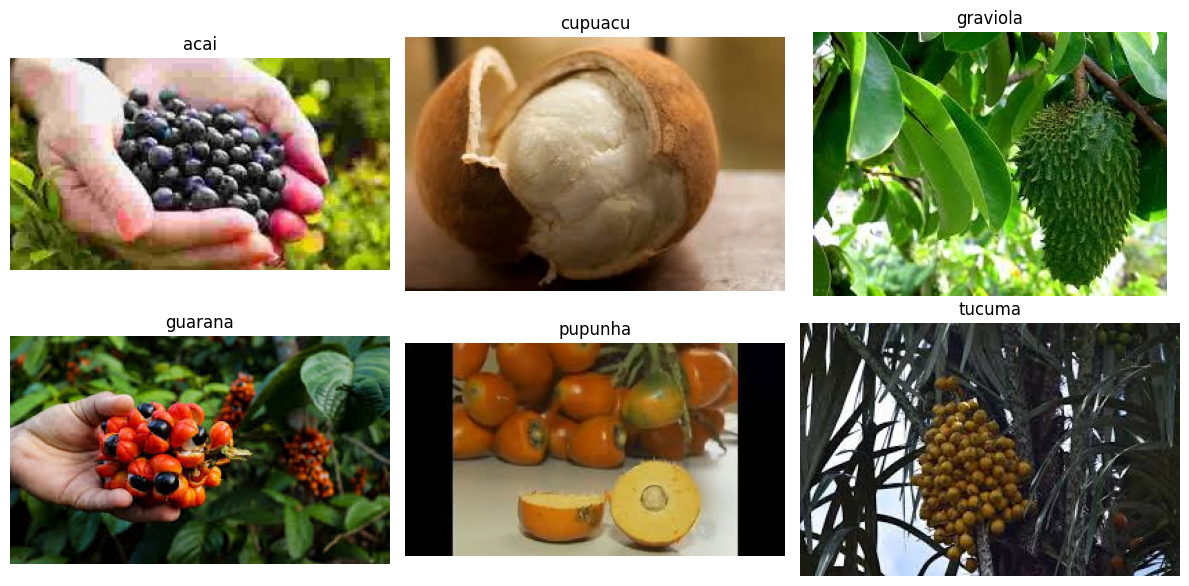

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Determine grid size
num_classes = len(selected_images)
rows = 2 # Fixed rows for layout
cols = (num_classes + rows - 1) // rows # Calculate columns dynamically for 2 rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
# Flatten axes for easy iteration if it's a 2D array, otherwise keep as 1D
axes = axes.flatten() if rows > 1 or cols > 1 else [axes]

for i, ax in enumerate(axes):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf
from tensorflow import keras

image_size = (28, 28)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

# To check the shape of a batch:
for images, labels in train_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 28, 28, 3)
Labels shape: (32,)


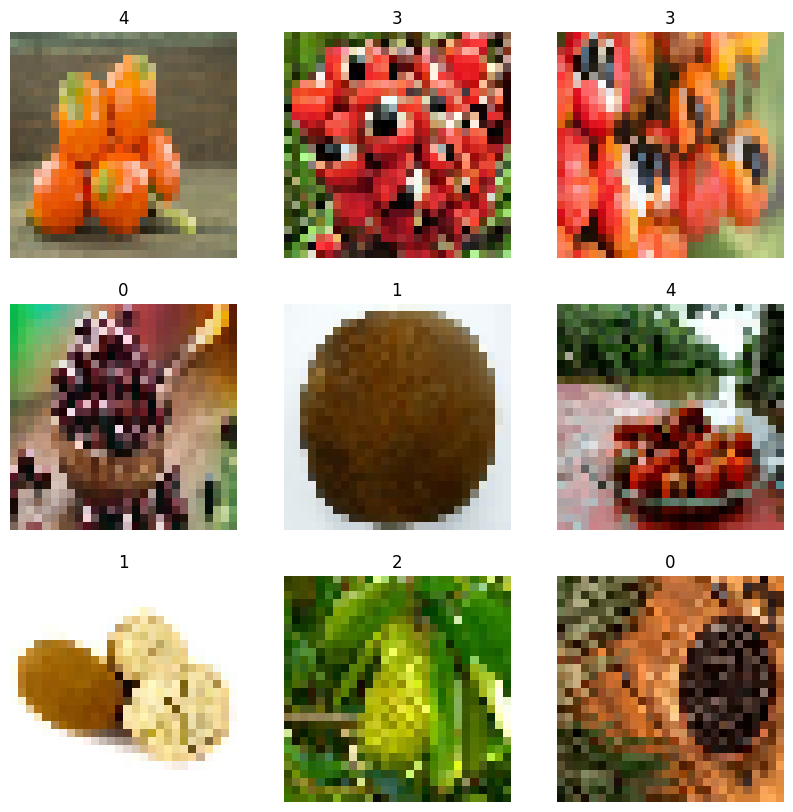

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # Takes one batch of images from the dataset (train_ds).
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
    plt.show()

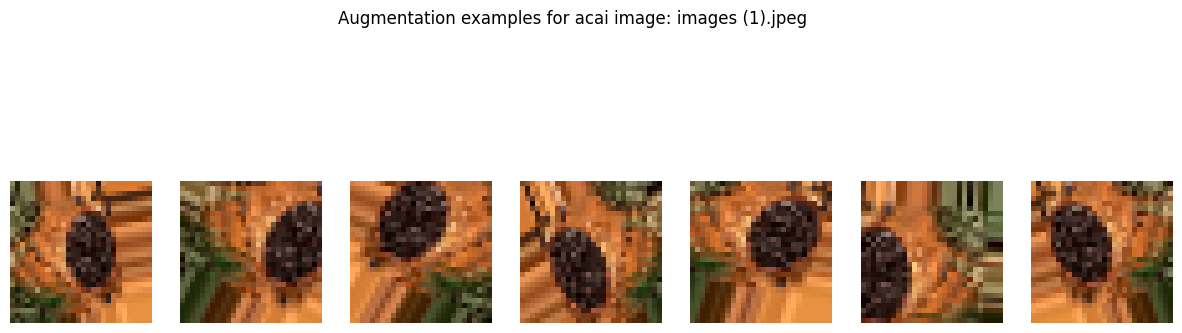

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load an example image from the training dataset for augmentation visualization
# We'll pick one from the 'acai' class for consistency
example_img_path = os.path.join(train_dir, class_names[0], os.listdir(os.path.join(train_dir, class_names[0]))[0])

img = load_img(example_img_path, target_size=image_size) # Use image_size (28, 28) from previous steps
x = img_to_array(img) # Convert to NumPy array
x = np.expand_dims(x, axis=0)

# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)

# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))
for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype('uint8'))
    ax[i].axis('off')
plt.suptitle(f"Augmentation examples for {class_names[0]} image: {os.path.basename(example_img_path)}")
plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras import layers

# Sample implementation of tf.keras.layers augmentation
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    """Applies a series of random augmentations to the input images."""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Example of how to apply it to a batch from train_ds
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    print(f"Original batch shape: {images.shape}")
    print(f"Augmented batch shape: {augmented_images.shape}")

Original batch shape: (32, 28, 28, 3)
Augmented batch shape: (32, 28, 28, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        32,454 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,350 (130.27 KB)

 Trainable params: 33,350 (130.27 KB)

 Non-trainable params: 0 (0.00 B)

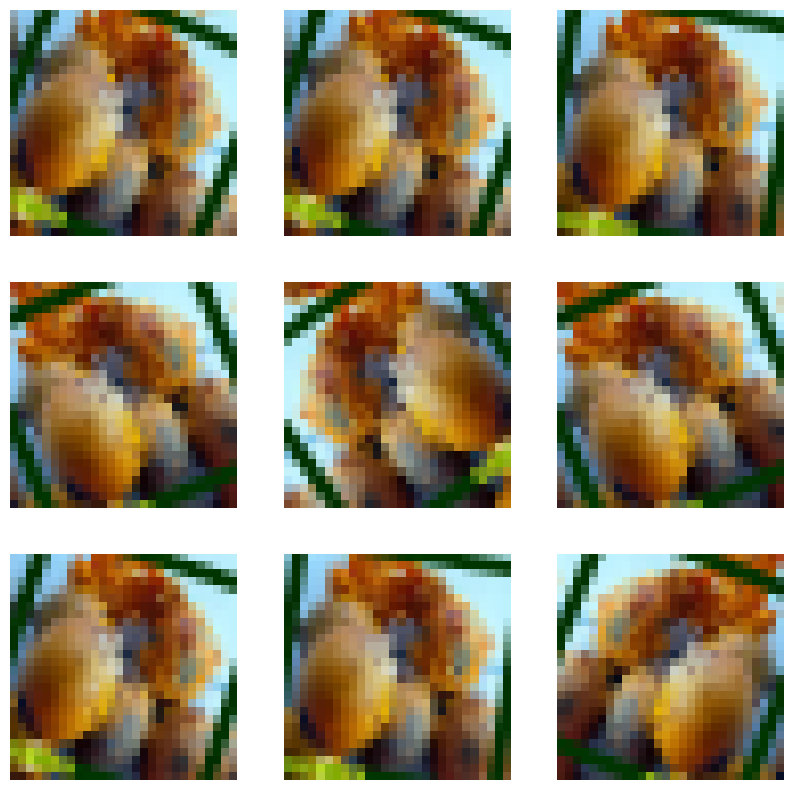

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Define the model with augmentation layers
# Note: Using image_size (28, 28) from previous cells instead of (128, 128)
model = keras.Sequential([
    layers.Input(shape=(28, 28, 3)),
    *data_augmentation_layers,
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

# Visualizing augmented images from a batch
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        # Display the first image of the augmented batch for comparison
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.show()

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the input shape based on previous steps
input_shape = (image_size[0], image_size[1], 3)

# Define the model with augmentation and rescaling as internal layers
model = keras.Sequential([
    layers.Input(shape=input_shape),
    # 1. Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    # 2. Rescaling (Recommended to do after augmentation if augmentation is in-model)
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 28, 28, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,094 (879.27 KB)

 Trainable params: 225,094 (879.27 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Define the updated CNN model
model = keras.Sequential([
    layers.Input(shape=(28, 28, 3)),

    # Data Augmentation & Rescaling
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Rescaling(1./255),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])

# 2. Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 3. Train the model
print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# 4. Summary
model.summary()

Starting training...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.1667 - loss: 3.3876 - val_accuracy: 0.2222 - val_loss: 1.7773
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4028 - loss: 2.0413 - val_accuracy: 0.0556 - val_loss: 1.7865
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5694 - loss: 1.5675 - val_accuracy: 0.0556 - val_loss: 1.7923
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5139 - loss: 1.6307 - val_accuracy: 0.1111 - val_loss: 1.7938
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5417 - loss: 1.2661 - val_accuracy: 0.2222 - val_loss: 1.7981
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6389 - loss: 0.8640 - val_accuracy: 0.2222 - val_loss: 1.7832
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6389 - loss: 0.9096 - val_accuracy: 0.2222 - val_loss: 1.7621
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7083 - loss: 0.8872 - val_accuracy: 0.22

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 28, 28, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,052 (2.58 MB)

 Trainable params: 225,286 (880.02 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 450,574 (1.72 MB)

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense

# Data augmentation layers
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Define the model using the Sequential API based on the user's sample structure
model = Sequential([
    # Data augmentation applied using Lambda layer
    layers.Lambda(data_augmentation, input_shape=(28, 28, 3)),
    # Rescaling layer to normalize pixel values
    layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output
    Flatten(),

    # Fully Connected Layers
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer (adjusted to 6 classes for our fruit dataset)
    Dense(len(class_names), activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,32

 Total params: 820,422 (3.13 MB)

 Trainable params: 818,438 (3.12 MB)

 Non-trainable params: 1,984 (7.75 KB)

Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.

• Use Data Augmentation to increase the number of training image.

• Use deeper model with BN and DropOut layer as presented above.

• Understand the Model Summary and Training Behavior.

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Define Data Augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. Build a Deeper Model with BN and Dropout
model = Sequential([
    layers.Input(shape=(28, 28, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

# 3. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train and Observe Behavior
print("Training the improved model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    verbose=1
)

# 5. Display Summary
model.summary()

Training the improved model...
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step - accuracy: 0.2361 - loss: 2.5151 - val_accuracy: 0.2778 - val_loss: 1.7903
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2917 - loss: 2.2417 - val_accuracy: 0.2222 - val_loss: 1.7545
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4444 - loss: 1.6076 - val_accuracy: 0.2778 - val_loss: 1.7282
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4028 - loss: 1.8150 - val_accuracy: 0.2778 - val_loss: 1.7073
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5139 - loss: 1.4498 - val_accuracy: 0.2222 - val_loss: 1.6919
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4861 - loss: 1.7766 - val_accuracy: 0.2222 - val_loss: 1.6845
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6250 - loss: 1.0715 - val_accuracy: 0.2222 - val_loss: 1.6713
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5833 - loss: 1.1736 - val_acc

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,173,716 (4.48 MB)

 Trainable params: 390,918 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 781,838 (2.98 MB)

5 Task - 2:

To - Do:

• Implement transfer learning using a pre-trained model trained on ImageNet weights, freeze the
layers of the model, and fit it only on the output layer to classify the fruits dataset.

• Evaluate the model’s performance and generate an inference output and classification report.

• Did the performance improved compared to training from scratch.

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Standard size for MobileNetV2
IMG_SIZE = (224, 224)
batch_size = 32

# Reload datasets with the correct size for the pre-trained model
train_ds_tl, val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='both',
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=batch_size
)

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_tl = train_ds_tl.prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [17]:
# 1. Create base model from the pre-trained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')

# 2. Freeze the base model
base_model.trainable = False

# 3. Add a classification head
model_tl = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model_tl.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
print("Training Transfer Learning Model...")
history_tl = model_tl.fit(train_ds_tl, validation_data=val_ds_tl, epochs=15)

Training Transfer Learning Model...
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1528 - loss: 2.3271 - val_accuracy: 0.1667 - val_loss: 2.0263
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 932ms/step - accuracy: 0.4028 - loss: 1.6174 - val_accuracy: 0.2778 - val_loss: 1.9238
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4722 - loss: 1.4058 - val_accuracy: 0.3333 - val_loss: 1.8168
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 892ms/step - accuracy: 0.5417 - loss: 1.1329 - val_accuracy: 0.3889 - val_loss: 1.6178
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7639 - loss: 0.7520 - val_accuracy: 0.4444 - val_loss: 1.3996
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8750 - loss: 0.6739 - val_accuracy: 0.5556 - val_loss: 1.2255
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 961ms/step - accuracy: 0.9028 - loss: 0.5655 - val_accuracy: 0.6111 - val_loss: 1.1043
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 928ms/step - accuracy: 0.9306 - loss: 0.4428 - val_acc

In [19]:
# Generate Inference Output and Classification Report
y_true = []
y_pred = []

for x, y in val_ds_tl:
    preds = model_tl.predict(x)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Classification Report:
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         3
     cupuacu       1.00      1.00      1.00         4
    graviola       1.00      1.00      1.00         1
     guarana       0.50      1.00      0.67         1
     pupunha       0.50      0.75      0.60         4
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.78        18
   macro avg       0.83      0.86      0.81        18
weighted avg       0.86      0.78      0.77        18

